### Look at Tallo and BAAD for species in FATES-MRV projects

#### Libraries 

In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd

#import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib import cm

import math as m
from scipy.optimize import curve_fit
from scipy.stats import linregress

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
cultivo_sp = ['Pinus pseudostrobus',
'Pinus leiophylla',
'Pinus devoniana',
'Pinus lawsonii',
'Pinus pringlei',
'Pinus teocote',
'Abies religiosa',
'Quercus laurina',
'Quercus rugosa',
'Quercus obtusata',
'Quercus resinosa',
'Arbutus xalapensis',
'Alnus jorullensis',
'Clethra mexicana',
'Ternstroemia pringlei',
'Ilex brandegeana']


### Read in Tallo and BAAD data

In [3]:
# Note these dataframes were processed in the notebook  v2_Tallo_analysis_global.ipynb
df_tallo = pd.read_csv('/global/homes/j/jneedham/trait_data/df_tallo.csv')
df_baad = pd.read_csv('/global/homes/j/jneedham/trait_data/df_baad.csv')


In [4]:
print(df_tallo.head(3))
#  remove rows with NA for species
df_tallo = df_tallo.dropna(subset=['species'])

            species  latitude  longitude   dbh  height height_outlier  \
0  Betula pubescens    67.395     28.723  10.0     5.6              N   
1       Picea abies    67.395     28.723  10.0     6.6              N   
2       Picea abies    67.395     28.723  10.0     8.5              N   

   crown_radius_m crown_radius_outlier                       PFT_tallo  \
0            1.65                    N             broadleaf_extratrop   
1            0.85                    N  needleleaf_evergreen_extratrop   
2            0.75                    N  needleleaf_evergreen_extratrop   

   crown_area  
0    8.552986  
1    2.269801  
2    1.767146  


### USA

#### Hybrid Populus tremula × Populus alba

In [5]:
# find the two 'parent' species
populus_alba = df_tallo[df_tallo['species'].str.contains('Populus alba', case=False)]
populus_tremula = df_tallo[df_tallo['species'].str.contains('Populus tremula', case=False)]

populus = pd.concat([populus_alba, populus_tremula], axis=0)

In [6]:
def d2hmc (d, p1, p2, p3) :
    h = (p1 * d**p2) / (p3 + d**p2)
    return h

initial_guess = [58.0, 0.73, 21.8]


In [7]:
pop_h =  populus.dropna(subset=['height', 'dbh'])
# remove outliers
pop_h = pop_h[pop_h['height_outlier'] == 'N']
pop_h = pop_h[pop_h['dbh'] < 100]
dbh_pop_h = np.arange(1,pop_h['dbh'].max(),1)

height_ps_pop, height_cov_pop = curve_fit(f=d2hmc, xdata=np.array(pop_h['dbh']), ydata=np.array(pop_h['height']),
                                           p0=initial_guess)
pop_curve_h = [d2hmc(d, height_ps_pop[0], height_ps_pop[1], height_ps_pop[2])  for  d  in dbh_pop_h]

palba_h = pop_h[pop_h['species']  ==  'Populus alba']
ptrem_h = pop_h[pop_h['species']  ==  'Populus tremula']

print(height_ps_pop)

[30.84653668  1.10525761 18.05775934]


In [8]:
def d2ca (d, p1, p2) :
    ca = p1 * d ** p2
    return ca

In [9]:
pop_ca = populus.dropna(subset=['crown_area','dbh'])
# remove outliers
pop_ca = pop_ca[pop_ca['crown_radius_outlier'] == 'N']
pop_ca = pop_ca[pop_ca['dbh'] < 100]
dbh_pop_ca = np.arange(1,pop_ca['dbh'].max(),1)

initial_guess = [0.07, 1.3]

ca_ps_pop, ca_cov_pop = curve_fit(f=d2ca, xdata=np.array(pop_ca['dbh']), ydata=np.array(pop_ca['crown_area']), p0=initial_guess)

pop_curve_ca = [d2ca(d, ca_ps_pop[0], ca_ps_pop[1])  for  d  in dbh_pop_ca]
palba_ca = pop_ca[pop_ca['species']  ==  'Populus alba']
ptrem_ca = pop_ca[pop_ca['species']  ==  'Populus tremula']

print(ca_ps_pop)

[0.33416457 1.31263564]


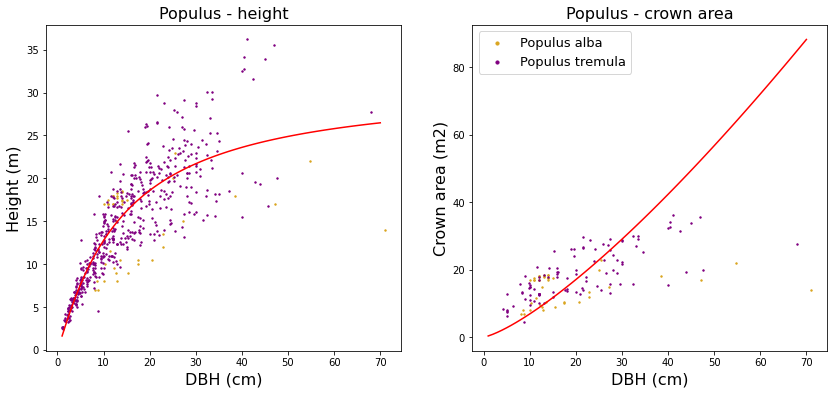

In [10]:
fig, ((fax0,fax1)) = plt.subplots(nrows=1, ncols=2, figsize=(14,6))

fax0.scatter(palba_h.dbh, palba_h.height, c='goldenrod', s=2, label = 'Populus alba')
fax0.scatter(ptrem_h.dbh, ptrem_h.height, c='purple', s=2, label = 'Populus tremula')
fax0.plot(dbh_pop_h, pop_curve_h, color='red')
fax0.set_title('Populus - height', fontsize=16)
fax0.set_ylabel('Height (m)', fontsize=16)
fax0.set_xlabel('DBH (cm)', fontsize=16)

    
fax1.scatter(palba_ca.dbh, palba_ca.height, c='goldenrod', s=2, label = 'Populus alba')
fax1.scatter(ptrem_ca.dbh, ptrem_ca.height, c='purple', s=2, label = 'Populus tremula')
fax1.plot(dbh_pop_ca, pop_curve_ca, color='red')
fax1.set_title('Populus - crown area', fontsize=16)
fax1.set_ylabel('Crown area (m2)', fontsize=16)
fax1.set_xlabel('DBH (cm)', fontsize=16)
fax1.legend(fontsize=13)    

# Get the legend object
legend = fax1.get_legend()
for legobj in legend.legendHandles:
    legobj.set_sizes([10])
    
plt.savefig('/global/homes/j/jneedham/jupyter_notebooks/mrv_figs/Populus_CA_height.png', facecolor='white')    

### Get the wood  density of populus - mean of the two species
These species aren't  in BAAD so we can't get AGB parameters 

In [11]:
df_wd = pd.read_csv('/global/homes/j/jneedham/trait_data/wood_density_utf8.csv')

# remove the outlier
max_index = df_wd['wood_dens'].idxmax()
print(df_wd.loc[max_index])

df_wd = df_wd[df_wd['wood_dens'] < 20.0]

df_wd_mean = df_wd.groupby('ScientificName')['wood_dens'].mean().reset_index()
print(df_wd_mean.head(4))

ScientificName    Cecropia glaziovii
wood_dens                      22.15
Name: 49328, dtype: object
            ScientificName  wood_dens
0  ARCTOSTAPHYLOS UVA-URSI   0.515767
1       Abarema adenophora   0.511729
2      Abarema barbouriana   0.418682
3    Abarema brachystachya   0.537852


In [12]:
# populus wd
pop_alba_wd = df_wd_mean[df_wd_mean['ScientificName'].str.contains('Populus alba', case=False)]
pop_trem_wd = df_wd_mean[df_wd_mean['ScientificName'].str.contains('Populus tremula', case=False)]

print(pop_alba_wd)
print(pop_trem_wd)

pop_wd = np.mean([pop_alba_wd.wood_dens, pop_trem_wd.wood_dens])

print(pop_wd)

     ScientificName  wood_dens
8404   Populus alba   0.419722
       ScientificName  wood_dens
8432  Populus tremula   0.522682
0.4712021328783584


### Make a dataframe of these values

In [13]:
data = {'d2h1':[height_ps_pop[0]],'d2h2':[height_ps_pop[1]],'d2h3':[height_ps_pop[2]]}
poplar_params = pd.DataFrame(data)
poplar_params['wood_density'] = pop_wd
poplar_params['d2ca'] = ca_ps_pop[0]
poplar_params['d2bl2'] = ca_ps_pop[1]
poplar_params


,d2h1,d2h2,d2h3,wood_density,d2ca,d2bl2
0,30.846537,1.105258,18.057759,0.471202,0.334165,1.312636


### For the remaining species filter by east coast of USA and get deciduous broadleaf and evergreen needleleaf

Text(0.5, 1.0, 'All species')

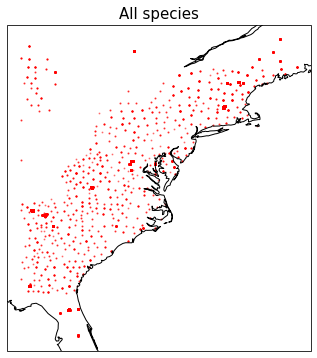

In [14]:
df_tallo_usae = df_tallo[(df_tallo['latitude'] >= 25) & (df_tallo['latitude'] <= 55) & 
                         (df_tallo['longitude'] >= -85) & (df_tallo['longitude'] <= -67)]


fig1, ((f1ax0)) = plt.subplots(nrows=1, ncols=1,  subplot_kw={'projection': ccrs.PlateCarree()},
                                                   figsize=(16,6))

f1ax0.scatter(df_tallo_usae.longitude, df_tallo_usae.latitude, color='red', s=1, marker='o',  alpha=0.4, transform=ccrs.PlateCarree())
f1ax0.coastlines()
f1ax0.set_title('All species', fontsize=15)

In [15]:
df_tallo_usae['PFT_tallo'].unique()

array(['broadleaf_extratrop', 'broadleaf_deciduous_extratrop',
       'needleleaf_extratrop', 'needleleaf_evergreen_extratrop'],
      dtype=object)

In [16]:
# Let's assume all broadleaf are deciduous and all needleleaf are evergreen
def condition(x) : 
    if x == 'broadleaf_extratrop':
        return 'broadleaf_deciduous_extratrop'
    elif x == 'needleleaf_extratrop': 
        return 'needleleaf_evergreen_extratrop'
    else : 
        return x
    
df_tallo_usae.loc[:,('PFT_tallo')] = df_tallo_usae.loc[:,('PFT_tallo')].apply(condition).values

print(df_tallo_usae['PFT_tallo'].unique())

['broadleaf_deciduous_extratrop' 'needleleaf_evergreen_extratrop']


/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [19]:
len(df_tallo_usae.species.unique())

160

#### Fit height

Broadleaf deciduous
[46.69680808  0.92675562 28.94467906]
Needleleaf evergreen
[52.69707617  0.94855988 46.79252608]


Text(0.5, 0.01, 'DBH (cm)')

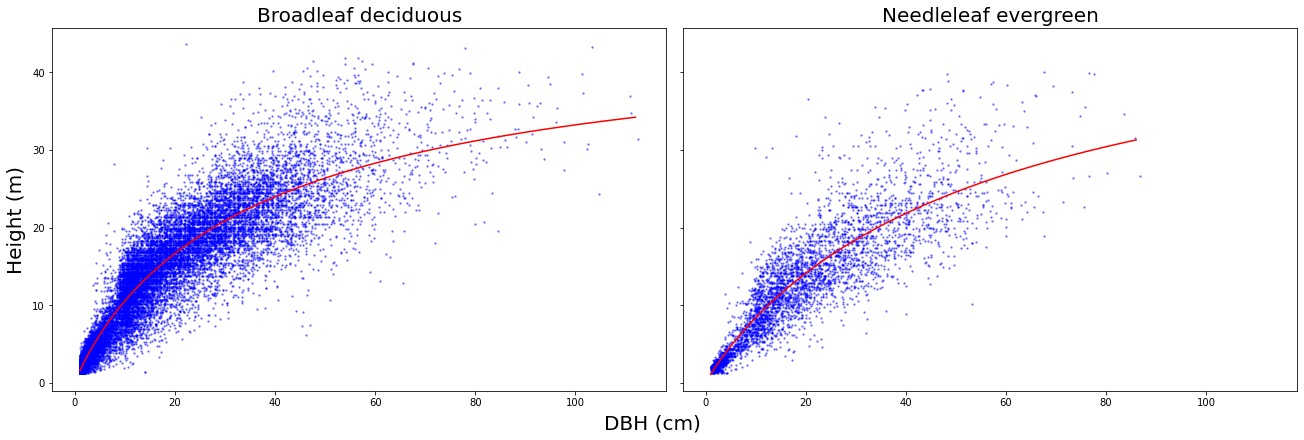

In [17]:
initial_guess = [58.0, 0.73, 21.8]

height_ps_df = []

titles = ['Broadleaf deciduous', 'Needleleaf evergreen']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18,6), sharex=True, sharey=True, constrained_layout=True)
  
for i  in range(0,2): 
    if i == 0: 
        df =  df_tallo_usae[df_tallo_usae['PFT_tallo'] == 'broadleaf_deciduous_extratrop']
    elif i == 1:
        df =  df_tallo_usae[df_tallo_usae['PFT_tallo'] == 'needleleaf_evergreen_extratrop']
   

    df =  df.dropna(subset=['height', 'dbh'])
    # remove outliers
    df = df[df['height_outlier'] == 'N']
    df = df[df['dbh'] < 175]
    dbh_df = np.arange(1,df['dbh'].max(),1)

    height_ps_df.append(curve_fit(f=d2hmc, xdata=np.array(df['dbh']), ydata=np.array(df['height']),
                                               p0=initial_guess)[0])
    
    print(titles[i])
    print(height_ps_df[i])
    
    df_curve = [d2hmc(d, height_ps_df[i][0], height_ps_df[i][1], height_ps_df[i][2])  for  d  in dbh_df]


    axs[i].scatter(df.dbh, df.height, c='blue', s=2, alpha = 0.4)
    axs[i].plot(dbh_df, df_curve, color='red')
    axs[i].set_title(titles[i], fontsize=20)
    
fig.supylabel('Height (m)', fontsize=20)
fig.supxlabel('DBH (cm)', fontsize=20)


In [18]:
print(height_ps_df)

[array([46.69680808,  0.92675562, 28.94467906]), array([52.69707617,  0.94855988, 46.79252608])]


### Convert to a dataframe

In [19]:
df_pft6 = pd.DataFrame(height_ps_df, columns=['d2h1','d2h2','d2h3'])
df_pft6

,d2h1,d2h2,d2h3
0,46.696808,0.926756,28.944679
1,52.697076,0.948560,46.792526


#### Fit crown areas 

[0.43697662 1.36563374]
[0.20180924 1.46388739]


Text(0.5, 0.01, 'DBH (cm)')

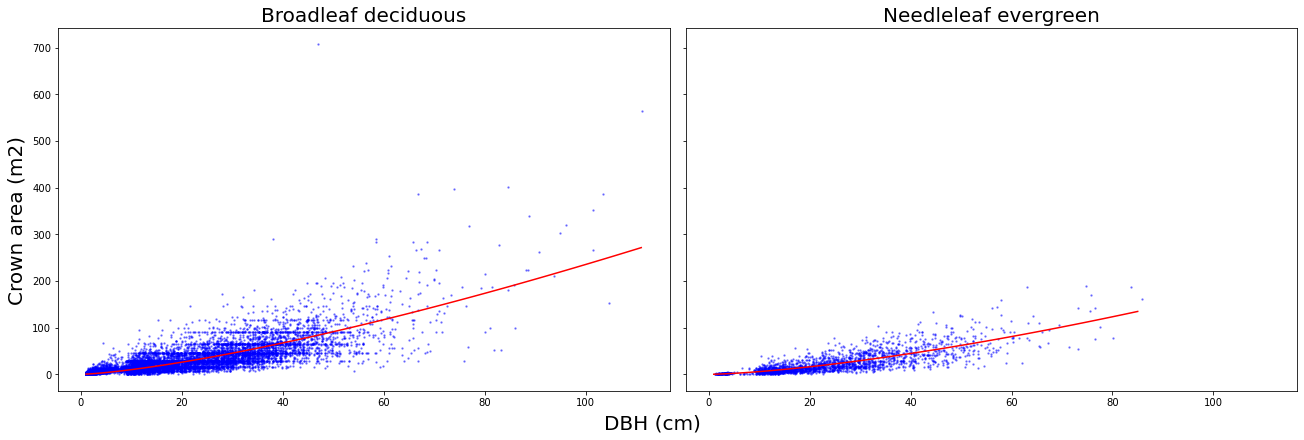

In [20]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18,6), sharex=True, sharey=True, constrained_layout=True)

ca_ps_df = []

for i  in range(0,2): 
    if i == 0: 
        df =  df_tallo_usae[df_tallo_usae['PFT_tallo'] == 'broadleaf_deciduous_extratrop']
    elif i == 1:
        df =  df_tallo_usae[df_tallo_usae['PFT_tallo'] == 'needleleaf_evergreen_extratrop']
   
    df =  df.dropna(subset=['crown_area', 'dbh'])
    # remove outliers
    df = df[df['crown_radius_outlier'] == 'N']
    dbh_df = np.arange(1,df['dbh'].max(),1)

    axs[i].scatter(df.dbh, df.crown_area, c='blue', s=2, alpha = 0.4)
    axs[i].set_title(titles[i], fontsize=20)
    
    ca_ps_df.append(curve_fit(f=d2ca, xdata=np.array(df['dbh']), ydata=np.array(df['crown_area']),
                                               p0=[0.07, 1.3])[0])
    
    print(ca_ps_df[i])
    
    df_curve = [d2ca(d, ca_ps_df[i][0], ca_ps_df[i][1])  for  d  in dbh_df]
    axs[i].plot(dbh_df, df_curve, color='red')

fig.supylabel('Crown area (m2)', fontsize=20)
fig.supxlabel('DBH (cm)', fontsize=20)


In [21]:
df_pft6['d2ca'] = [ca_ps_df[0][0],  ca_ps_df[1][0]]
df_pft6['d2bl2'] =  [ca_ps_df[0][1],ca_ps_df[1][1]]
df_pft6

,d2h1,d2h2,d2h3,d2ca,d2bl2
0,46.696808,0.926756,28.944679,0.436977,1.365634
1,52.697076,0.948560,46.792526,0.201809,1.463887


#### Wood density

In [22]:
# Subset BAAD data by east coast USA

Text(0.5, 1.0, 'All species')

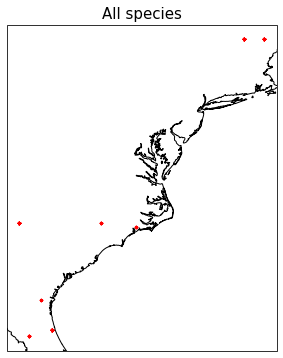

In [23]:
df_baad_usae = df_baad[(df_baad['latitude'] >= 25) & (df_baad['latitude'] <= 55) & 
                         (df_baad['longitude'] >= -85) & (df_baad['longitude'] <= -67)]


fig1, ((f1ax0)) = plt.subplots(nrows=1, ncols=1,  subplot_kw={'projection': ccrs.PlateCarree()},
                                                   figsize=(16,6))

f1ax0.scatter(df_baad_usae.longitude, df_baad_usae.latitude, color='red', s=5, marker='o',  alpha=0.4, transform=ccrs.PlateCarree())
f1ax0.coastlines()
f1ax0.set_title('All species', fontsize=15)

In [24]:
# Merge DataFrames based on matching values in 'x' and 's'
merged_df = df_baad_usae.merge(df_wd_mean, left_on='species', right_on='ScientificName', how='left')
merged_df['wd'] = merged_df['wood_dens'].fillna(merged_df['wd'])
merged_df = merged_df.drop(columns=['wood_dens'])
df_baad_usae = merged_df

In [25]:
print(df_baad_usae.head(3))

print(df_baad_usae['PFT_baad'].unique())

                         PFT_baad    family      species  latitude  longitude  \
0  needleleaf_evergreen_extratrop  Pinaceae  Pinus taeda    34.823    -77.303   
1  needleleaf_evergreen_extratrop  Pinaceae  Pinus taeda    34.823    -77.303   
2  needleleaf_evergreen_extratrop  Pinaceae  Pinus taeda    34.823    -77.303   

    dbh  height  crown_area       agb        wd     bleaf ScientificName  
0  5.23    4.37         NaN  5.452473  0.367205  1.694821    Pinus taeda  
1  5.31    4.22         NaN  4.368249  0.367205  1.343333    Pinus taeda  
2  1.70    2.64         NaN  0.817512  0.367205  0.246963    Pinus taeda  
['needleleaf_evergreen_extratrop' 'broadleaf_deciduous_extratrop']


In [26]:
wd_df = df_baad_usae.groupby(['PFT_baad']).mean()

In [27]:
print(wd_df)

                                 latitude  longitude        dbh     height  \
PFT_baad                                                                     
broadleaf_deciduous_extratrop   40.682203 -75.754237  17.915763  14.733263   
needleleaf_evergreen_extratrop  31.749347 -80.407036   7.020398   5.264422   

                                crown_area         agb        wd     bleaf  
PFT_baad                                                                    
broadleaf_deciduous_extratrop          NaN  363.901880  0.582007  5.483217  
needleleaf_evergreen_extratrop    2.009121   19.379993  0.371920  2.558915  


In [27]:
df_pft6['wood_density'] =  [wd_df['wd'][0],wd_df['wd'][1]]
df_pft6

,d2h1,d2h2,d2h3,d2ca,d2bl2,wood_density
0,46.696808,0.926756,28.944679,0.436977,1.365634,0.582007
1,52.697076,0.948560,46.792526,0.201809,1.463887,0.371920


#### AGB 

[0.08187483 1.02066147]


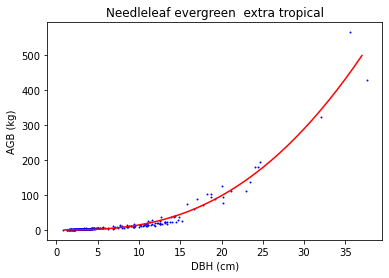

In [28]:
# Needleleaf evergreen extra tropical 
nleex = df_baad_usae[df_baad_usae.PFT_baad=='needleleaf_evergreen_extratrop']
nleex =  nleex.dropna(subset=['agb', 'dbh'])
dbh_nleex = np.arange(1,nleex['dbh'].max(),1)

initial_guess = [0.0673, 0.976]

def dh2bagw_nleex (d, p1, p2) :
    
    # set fixed parameters
    wd = 0.371920
    h1 = 52.69707617
    h2 = 0.94855988
    h3 = 46.79252608
    
    h = (h1 * d**h2) / (h3 + d*h2)
    
    agb = ( p1 * (wd * d**2 * h)**p2 ) / 2
    
    return agb


agb_ps_nleex, agb_cov_nleex = curve_fit(f=dh2bagw_nleex, xdata=np.array(nleex['dbh']), ydata=np.array(nleex['agb']),
                                           p0=initial_guess)

dbh_nleex = np.arange(1,nleex['dbh'].max(),1)

nleex_curve = [dh2bagw_nleex(d, agb_ps_nleex[0], agb_ps_nleex[1])  for  d  in dbh_nleex]

plt.scatter(nleex.dbh, nleex.agb, s=0.9, color='blue')
plt.plot(dbh_nleex, nleex_curve, color='red')
plt.xlabel('DBH (cm)')
plt.ylabel('AGB (kg)')
plt.title('Needleleaf evergreen  extra tropical')

print(agb_ps_nleex)

[0.12918309 0.981921  ]


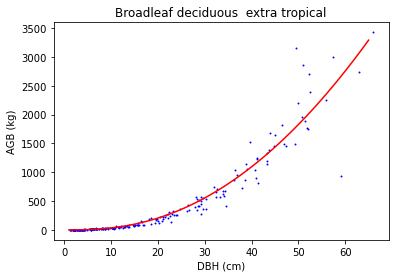

In [29]:
# Broadleaf deciduous extra tropical 
bldex = df_baad_usae[df_baad_usae.PFT_baad=='broadleaf_deciduous_extratrop']
bldex =  bldex.dropna(subset=['agb', 'dbh'])
dbh_bldex = np.arange(1,bldex['dbh'].max(),1)

initial_guess = [0.0673, 0.976]

def dh2bagw_bldex (d, p1, p2) :
    
    # set fixed parameters
    wd = 0.582007
    h1 = 46.09820802
    h2 = 0.93277477
    h3 = 28.84758308
    
    h = (h1 * d**h2) / (h3 + d*h2)
    
    agb = ( p1 * (wd * d**2 * h)**p2 ) / 2
    
    return agb


agb_ps_bldex, agb_cov_bldex = curve_fit(f=dh2bagw_bldex, xdata=np.array(bldex['dbh']), ydata=np.array(bldex['agb']),
                                           p0=initial_guess)

dbh_bldex = np.arange(1,bldex['dbh'].max(),1)

bldex_curve = [dh2bagw_bldex(d, agb_ps_bldex[0], agb_ps_bldex[1])  for  d  in dbh_bldex]

plt.scatter(bldex.dbh, bldex.agb, s=0.9, color='blue')
plt.plot(dbh_bldex, bldex_curve, color='red')
plt.xlabel('DBH (cm)')
plt.ylabel('AGB (kg)')
plt.title('Broadleaf deciduous  extra tropical')

print(agb_ps_bldex)

In [30]:
df_pft6['agb1'] = [agb_ps_bldex[0], agb_ps_nleex[0]]
df_pft6['agb2'] = [agb_ps_bldex[1], agb_ps_nleex[1]]
df_pft6['pft'] = ['bldex','nleex']
df_pft6 = df_pft6.set_index('pft')
df_pft6

,d2h1,d2h2,d2h3,d2ca,d2bl2,wood_density,agb1,agb2
pft,,,,,,,,
bldex,46.696808,0.926756,28.944679,0.436977,1.365634,0.582007,0.129183,0.981921
nleex,52.697076,0.948560,46.792526,0.201809,1.463887,0.371920,0.081875,1.020661


In [31]:
df_pft6.to_csv('/global/homes/j/jneedham/FATES-MRV/allom_scripts/pft6_params.csv')

In [32]:
poplar_params['agb1'] = [agb_ps_bldex[0]]
poplar_params['agb2'] = [agb_ps_bldex[1]]
poplar_params

,d2h1,d2h2,d2h3,wood_density,d2ca,d2bl2,agb1,agb2
0,30.846537,1.105258,18.057759,0.471202,0.334165,1.312636,0.129183,0.981921


In [33]:
poplar_params.to_csv('/global/homes/j/jneedham/FATES-MRV/allom_scripts/poplar_params.csv')

### AGB but using poplar height and wd parameters

In [ ]:
# Broadleaf deciduous extra tropical 
nleex = df_baad_usae[df_baad_usae.PFT_baad=='broadleaf_deciduous_extratrop']
nleex =  nleex.dropna(subset=['agb', 'dbh'])
dbh_nleex = np.arange(1,nleex['dbh'].max(),1)

initial_guess = [0.0673, 0.976]

def dh2bagw_nleex (d, p1, p2) :
    
    # set fixed parameters
    wd = 0.4712021328783584
    h1 = 30.84653668   
    h2 = 1.10525761
    h3 = 18.05775934
    
    h = (h1 * d**h2) / (h3 + d*h2)
    
    agb = ( p1 * (wd * d**2 * h)**p2 ) / 2
    
    return agb


agb_ps_nleex, agb_cov_nleex = curve_fit(f=dh2bagw_nleex, xdata=np.array(nleex['dbh']), ydata=np.array(nleex['agb']),
                                           p0=initial_guess)

dbh_nleex = np.arange(1,nleex['dbh'].max(),1)

nleex_curve = [dh2bagw_nleex(d, agb_ps_nleex[0], agb_ps_nleex[1])  for  d  in dbh_nleex]

plt.scatter(nleex.dbh, nleex.agb, s=0.9, color='blue')
plt.plot(dbh_nleex, nleex_curve, color='red')
plt.xlabel('DBH (cm)')
plt.ylabel('AGB (kg)')
plt.title('Broadleaf deciduous  extra tropical')

print(agb_ps_nleex)

#  Mexico

####  Oaks  - none in Mexco

In [ ]:
quercus = df_tallo[df_tallo['species'].str.contains('Quercus', case=False)]
print(quercus.head(3))
print(len(quercus))

In [ ]:
fig1, ((f1ax0)) = plt.subplots(nrows=1, ncols=1,  subplot_kw={'projection': ccrs.PlateCarree()},
                                                   figsize=(16,6))

f1ax0.scatter(quercus.longitude, quercus.latitude, color='red', s=4, marker='o', transform=ccrs.PlateCarree())
f1ax0.coastlines()
f1ax0.set_title('Quercus', fontsize=15)

In [ ]:
# Define the bounding box coordinates for Mexico
north_lat = 30.
south_lat = 14.
west_lon = -120.
east_lon = -86.

# Filter the DataFrame to include only coordinates within the bounding box
df_tallo_mx = df_tallo[
    (df_tallo['latitude'] >= south_lat) &
    (df_tallo['latitude'] <= north_lat) &
    (df_tallo['longitude'] >= west_lon) &
    (df_tallo['longitude'] <= east_lon)
]

fig1, ((f1ax0)) = plt.subplots(nrows=1, ncols=1,  subplot_kw={'projection': ccrs.PlateCarree()},
                                                   figsize=(16,6))

f1ax0.scatter(df_tallo_mx.longitude, df_tallo_mx.latitude, color='red', s=5, marker='o',  alpha=0.4, transform=ccrs.PlateCarree())
f1ax0.coastlines()
f1ax0.add_feature(cf.BORDERS)
f1ax0.set_title('All species', fontsize=15)
f1ax0.set_ylim(14, 33)
f1ax0.set_xlim(-120, -86) 

In [ ]:
len(df_tallo_mx['species'].unique())

In [ ]:
print(df_tallo_mx['PFT_tallo'].unique())

In [ ]:
# Divide into needleleaf and broadleaf -  regardless of deciduous/evergreen and extratropical/tropical
def condition(x) : 
    if x == 'broadleaf_tropical':
        return 'broadleaf'
    elif x == 'needleleaf_evergreen_extratrop': 
        return 'needleleaf'
    elif x == 'needleleaf_extratrop':
        return 'needleleaf'
    elif x == 'broadleaf_extratrop': 
        return 'broadleaf'
    elif x == 'broadleaf_deciduous_extratrop': 
        return 'broadleaf'
    elif x == 'broadleaf_evergreen_extratrop': 
        return 'broadleaf'
    else : 
        return x
    
df_tallo_mx.loc[:,('PFT_tallo')] = df_tallo_mx.loc[:,('PFT_tallo')].apply(condition).values

print(df_tallo_mx['PFT_tallo'].unique())

#### Height

In [ ]:
titles = ['Broadleaf']
initial_guess = [58.0, 0.73, 21.8]


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18,6), sharex=True, sharey=True, constrained_layout=True)
  
for i  in range(0,1): 
    if i == 0: 
        df =  df_tallo_mx[df_tallo_mx['PFT_tallo'] == 'broadleaf']
    elif i == 1:
        df =  df_tallo_mx[df_tallo_mx['PFT_tallo'] == 'needleleaf']
   

    df =  df.dropna(subset=['height', 'dbh'])
    # remove outliers
    df = df[df['height_outlier'] == 'N']
    dbh_df = np.arange(1,df['dbh'].max(),1)

    height_ps_df, height_cov_df = curve_fit(f=d2hmc, xdata=np.array(df['dbh']), ydata=np.array(df['height']),
                                               p0=initial_guess)
    
    print(height_ps_df)
    
    df_curve = [d2hmc(d, height_ps_df[0], height_ps_df[1], height_ps_df[2])  for  d  in dbh_df]


    axs[i].scatter(df.dbh, df.height, c='blue', s=2, alpha = 0.4)
    axs[i].plot(dbh_df, df_curve, color='red')
    axs[i].set_title(titles[i], fontsize=20)
    
fig.supylabel('Height (m)', fontsize=20)
fig.supxlabel('DBH (cm)', fontsize=20)


#### Crown area

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18,6), sharex=True, sharey=True, constrained_layout=True)
  
for i  in range(0,1): 
    if i == 0: 
        df =  df_tallo_mx[df_tallo_mx['PFT_tallo'] == 'broadleaf']
    elif i == 1:
        df =  df_tallo_mx[df_tallo_mx['PFT_tallo'] == 'needleleaf']
   

    df =  df.dropna(subset=['crown_area', 'dbh'])
    # remove outliers
    df = df[df['crown_radius_outlier'] == 'N']
    dbh_df = np.arange(1,df['dbh'].max(),1)

    axs[i].scatter(df.dbh, df.crown_area, c='blue', s=2, alpha = 0.4)
    axs[i].set_title(titles[i], fontsize=20)
    
    ca_ps_df, ca_cov_df = curve_fit(f=d2ca, xdata=np.array(df['dbh']), ydata=np.array(df['crown_area']),
                                               p0=[0.07, 1.3])
    
    print(ca_ps_df)
    
    df_curve = [d2ca(d, ca_ps_df[0], ca_ps_df[1])  for  d  in dbh_df]
    axs[i].plot(dbh_df, df_curve, color='red')
    
fig.supylabel('Crown area (m2)', fontsize=20)
fig.supxlabel('DBH (cm)', fontsize=20)


#### AGB - use BAAD data

In [ ]:
# Define the bounding box coordinates for Mexico
north_lat = 30.
south_lat = 14.
west_lon = -120.
east_lon = -86.

# Filter the DataFrame to include only coordinates within the bounding box
df_baad_mx = df_baad[
    (df_baad['latitude'] >= south_lat) &
    (df_baad['latitude'] <= north_lat) &
    (df_baad['longitude'] >= west_lon) &
    (df_baad['longitude'] <= east_lon)
]

print(df_baad_mx.head(3))

print(df_baad_mx.species.unique())

#### No species - from Mexican sites in BAAD